In [1]:
import pandas as pd
import pybedtools
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
all_loops  = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/ml_final_multiclassmodel.csv", sep=",")
all_loops.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'chr1', 'start1', 'end1', 'chr2',
       'start2', 'end2', 'status', 'ctrl_signal', 'rbp1_signal', 'log2FC',
       'log2FC_clipped', 'condition', 'distance', 'loop_id', 'comp_switch_A1',
       'comp_switch_A2', 'loop_class', 'source', 'CTCF_signal',
       'H3K27me3_signal', 'H3K4me3_signal', 'rad21_signal', 'GC_mean',
       'GC_diff', 'E1_anchor1_ctrl', 'E1_anchor1_rbp1', 'E1_anchor2_ctrl',
       'E1_anchor2_rbp1', 'delta_E1_anchor1', 'delta_E1_anchor2',
       'ATAC_signal'],
      dtype='object')

In [3]:
# loading the merged loops file
mega_loop_ctrl = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/megalooplist/mega_merged_loops_ctrl.bedpe", sep="\t", header=None, names=["chr1", "start1", "end1", "chr2", "start2", "end2"])
mega_loop_rbp1 = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/megalooplist/mega_merged_loops_rbp1.bedpe", sep="\t", header=None, names=["chr1", "start1", "end1", "chr2", "start2", "end2"])

In [4]:
slop_distance = 2500
ctrl_bed = pybedtools.BedTool("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/megalooplist/mega_merged_loops_ctrl.bedpe").sort()
eed_bed = pybedtools.BedTool("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/megalooplist/mega_merged_loops_rbp1.bedpe").sort()
shared = ctrl_bed.pair_to_pair(eed_bed, type='both', slop=slop_distance, is_sorted=False)
shared.count()
# this is loops present in both ctrl and eed

5969

In [5]:
shared_df = shared.to_dataframe().iloc[:, :6]
shared_df.columns = ["chr1", "start1", "end1", "chr2", "start2", "end2"]
#shared_df
shared_df = shared_df.drop_duplicates(subset=["chr1", "start1", "end1", "chr2", "start2", "end2"])
# CTRL-only (lost)
ctrl_lost = mega_loop_ctrl.merge(shared_df, how="left", indicator=True)
ctrl_lost = ctrl_lost[ctrl_lost["_merge"] == "left_only"].drop(columns="_merge")
# RBP1-only (gained)
rbp1_gained = mega_loop_rbp1.merge(shared_df, how="left", indicator=True)
rbp1_gained = rbp1_gained[rbp1_gained["_merge"] == "left_only"].drop(columns="_merge")

/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/pybedtools/bedtool.py:3756: UserWarning: Default names for filetype bed are:
['chrom', 'start', 'end', 'name', 'score', 'strand', 'thickStart', 'thickEnd', 'itemRgb', 'blockCount', 'blockSizes', 'blockStarts']
but file has 16 fields; you can supply custom names with the `names` kwarg
  warn(


In [6]:
ctrl_lost.value_counts()

chr1  start1    end1      chr2  start2    end2    
chrY  20562500  20567500  chrY  20732500  20737500    1
chr1  1112500   1117500   chr1  1262500   1267500     1
      1120000   1125000   chr1  1245000   1250000     1
      1772500   1777500   chr1  1892500   1897500     1
      2822500   2827500   chr1  3412500   3417500     1
                                                     ..
      6250000   6255000   chr1  6435000   6440000     1
      6555000   6560000   chr1  6645000   6650000     1
      6720000   6725000   chr1  6885000   6890000     1
                                7215000   7220000     1
      6790000   6795000   chr1  6890000   6895000     1
Name: count, Length: 13068, dtype: int64

In [7]:
rbp1_gained.value_counts()

chr1  start1    end1      chr2  start2    end2    
chrY  19432500  19437500  chrY  20742500  20747500    1
chr1  982500    987500    chr1  1272500   1277500     1
      1112500   1117500   chr1  1262500   1267500     1
      1762500   1767500   chr1  1892500   1897500     1
      1955000   1960000   chr1  2045000   2050000     1
                                                     ..
      8912500   8917500   chr1  8992500   8997500     1
      9122500   9127500   chr1  9192500   9197500     1
      9262500   9267500   chr1  9492500   9497500     1
      9272500   9277500   chr1  9572500   9577500     1
      9282500   9287500   chr1  9482500   9487500     1
Name: count, Length: 13241, dtype: int64

In [8]:
shared_df.value_counts()

chr1  start1    end1      chr2  start2    end2    
chrY  12922500  12927500  chrY  13342500  13347500    1
chr1  1952500   1957500   chr1  2042500   2047500     1
      2202500   2207500   chr1  2382500   2387500     1
      2412500   2417500   chr1  2552500   2557500     1
      3565000   3570000   chr1  3615000   3620000     1
                                                     ..
      9140000   9145000   chr1  9195000   9200000     1
      9285000   9290000   chr1  9450000   9455000     1
      9492500   9497500   chr1  9572500   9577500     1
      9782500   9787500   chr1  9862500   9867500     1
      9875000   9880000   chr1  9940000   9945000     1
Name: count, Length: 5968, dtype: int64

In [9]:
shared_df["status_slop"] = "shared_2.5kb"
ctrl_lost["status_slop"] = "lost_2.5kb"
rbp1_gained["status_slop"] = "gained_2.5kb"

In [10]:
# Combine
all = pd.concat([shared_df, ctrl_lost, rbp1_gained], ignore_index=True)
all

,chr1,start1,end1,chr2,start2,end2,status_slop
0,chr1,1952500,1957500,chr1,2042500,2047500,shared_2.5kb
1,chr1,2202500,2207500,chr1,2382500,2387500,shared_2.5kb
2,chr1,2412500,2417500,chr1,2552500,2557500,shared_2.5kb
3,chr1,3565000,3570000,chr1,3615000,3620000,shared_2.5kb
4,chr1,3912500,3917500,chr1,4822500,4827500,shared_2.5kb
...,...,...,...,...,...,...,...
32272,chrY,10945000,10950000,chrY,11290000,11295000,gained_2.5kb
32273,chrY,10982500,10987500,chrY,11292500,11297500,gained_2.5kb
32274,chrY,11292500,11297500,chrY,11722500,11727500,gained_2.5kb
32275,chrY,11530000,11535000,chrY,11760000,11765000,gained_2.5kb


In [11]:
all_loops

,Unnamed: 0.1,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,...,rad21_signal,GC_mean,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,ATAC_signal
0,0,0,chr1,1952500,1957500,chr1,2042500,2047500,shared,NaN,...,0.024018,0.5773,0.0494,NaN,NaN,NaN,NaN,NaN,NaN,0.078179
1,1,1,chr1,2202500,2207500,chr1,2382500,2387500,shared,NaN,...,0.063427,0.6135,0.0578,NaN,NaN,NaN,NaN,NaN,NaN,0.200288
2,2,2,chr1,2412500,2417500,chr1,2552500,2557500,shared,NaN,...,0.044699,0.6525,0.0102,NaN,NaN,NaN,NaN,NaN,NaN,0.069768
3,3,3,chr1,3490000,3495000,chr1,3615000,3620000,shared,NaN,...,0.024769,0.6002,0.0948,NaN,NaN,NaN,NaN,NaN,NaN,0.050523
4,4,4,chr1,3565000,3570000,chr1,3615000,3620000,shared,NaN,...,0.042592,0.5949,0.0842,NaN,NaN,NaN,NaN,NaN,NaN,0.067897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32272,32272,32272,chrY,10945000,10950000,chrY,11290000,11295000,gained,0.006078,...,0.026824,0.4545,0.0226,-0.064836,-0.140925,0.270996,0.177009,-0.076090,-0.093987,0.019050
32273,32273,32273,chrY,10982500,10987500,chrY,11292500,11297500,gained,0.007661,...,0.130330,0.4609,0.0026,0.120802,-0.100746,0.270996,0.177009,-0.221548,-0.093987,0.022277
32274,32274,32274,chrY,11292500,11297500,chrY,11722500,11727500,gained,0.001017,...,0.123878,0.4195,0.0854,0.270996,0.177009,0.409095,0.332632,-0.093987,-0.076464,0.022359
32275,32275,32275,chrY,11530000,11535000,chrY,11760000,11765000,gained,0.004674,...,0.112741,0.3788,0.0120,-1.192141,-1.204536,-1.229772,-1.167283,-0.012394,0.062489,0.019858


In [12]:
all_loops["status_slop"] = all["status_slop"]

In [13]:
all_loops.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'chr1', 'start1', 'end1', 'chr2',
       'start2', 'end2', 'status', 'ctrl_signal', 'rbp1_signal', 'log2FC',
       'log2FC_clipped', 'condition', 'distance', 'loop_id', 'comp_switch_A1',
       'comp_switch_A2', 'loop_class', 'source', 'CTCF_signal',
       'H3K27me3_signal', 'H3K4me3_signal', 'rad21_signal', 'GC_mean',
       'GC_diff', 'E1_anchor1_ctrl', 'E1_anchor1_rbp1', 'E1_anchor2_ctrl',
       'E1_anchor2_rbp1', 'delta_E1_anchor1', 'delta_E1_anchor2',
       'ATAC_signal', 'status_slop'],
      dtype='object')

In [14]:
slop_distance = 10000
shared = ctrl_bed.pair_to_pair(eed_bed, type='both', slop=slop_distance, is_sorted=False)
shared_df = shared.to_dataframe().iloc[:, :6]
shared_df.columns = ["chr1", "start1", "end1", "chr2", "start2", "end2"]
#shared_df
shared_df = shared_df.drop_duplicates(subset=["chr1", "start1", "end1", "chr2", "start2", "end2"])
# CTRL-only (lost)
ctrl_lost = mega_loop_ctrl.merge(shared_df, how="left", indicator=True)
ctrl_lost = ctrl_lost[ctrl_lost["_merge"] == "left_only"].drop(columns="_merge")
# RBP1-only (gained)
rbp1_gained = mega_loop_rbp1.merge(shared_df, how="left", indicator=True)
rbp1_gained = rbp1_gained[rbp1_gained["_merge"] == "left_only"].drop(columns="_merge")
shared_df["status_slop2"] = "shared_10kb"
ctrl_lost["status_slop2"] = "lost_10kb"
rbp1_gained["status_slop2"] = "gained_10kb"
# Combine
all = pd.concat([shared_df, ctrl_lost, rbp1_gained], ignore_index=True)
all_loops["status_slop2"] = all["status_slop2"]

/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/pybedtools/bedtool.py:3756: UserWarning: Default names for filetype bed are:
['chrom', 'start', 'end', 'name', 'score', 'strand', 'thickStart', 'thickEnd', 'itemRgb', 'blockCount', 'blockSizes', 'blockStarts']
but file has 16 fields; you can supply custom names with the `names` kwarg
  warn(


In [15]:
slop_distance = 0
shared = ctrl_bed.pair_to_pair(eed_bed, type='both', slop=slop_distance, is_sorted=False)
shared_df = shared.to_dataframe().iloc[:, :6]
shared_df.columns = ["chr1", "start1", "end1", "chr2", "start2", "end2"]
#shared_df
shared_df = shared_df.drop_duplicates(subset=["chr1", "start1", "end1", "chr2", "start2", "end2"])
# CTRL-only (lost)
ctrl_lost = mega_loop_ctrl.merge(shared_df, how="left", indicator=True)
ctrl_lost = ctrl_lost[ctrl_lost["_merge"] == "left_only"].drop(columns="_merge")
# RBP1-only (gained)
rbp1_gained = mega_loop_rbp1.merge(shared_df, how="left", indicator=True)
rbp1_gained = rbp1_gained[rbp1_gained["_merge"] == "left_only"].drop(columns="_merge")
shared_df["status_slop3"] = "shared_0kb"
ctrl_lost["status_slop3"] = "lost_0kb"
rbp1_gained["status_slop3"] = "gained_0kb"
# Combine
all = pd.concat([shared_df, ctrl_lost, rbp1_gained], ignore_index=True)
all_loops["status_slop3"] = all["status_slop3"]

/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/pybedtools/bedtool.py:3756: UserWarning: Default names for filetype bed are:
['chrom', 'start', 'end', 'name', 'score', 'strand', 'thickStart', 'thickEnd', 'itemRgb', 'blockCount', 'blockSizes', 'blockStarts']
but file has 16 fields; you can supply custom names with the `names` kwarg
  warn(


In [16]:
all_loops["status_slop3"]

0        shared_0kb
1        shared_0kb
2        shared_0kb
3        shared_0kb
4        shared_0kb
            ...    
32272    gained_0kb
32273    gained_0kb
32274    gained_0kb
32275    gained_0kb
32276    gained_0kb
Name: status_slop3, Length: 32277, dtype: object

In [17]:
allPlot=all_loops.loc[:, ["status", "status_slop", "status_slop2", "status_slop3"]]

In [18]:
allPlot
df_melted = allPlot.melt(var_name='Type', value_name='Class')

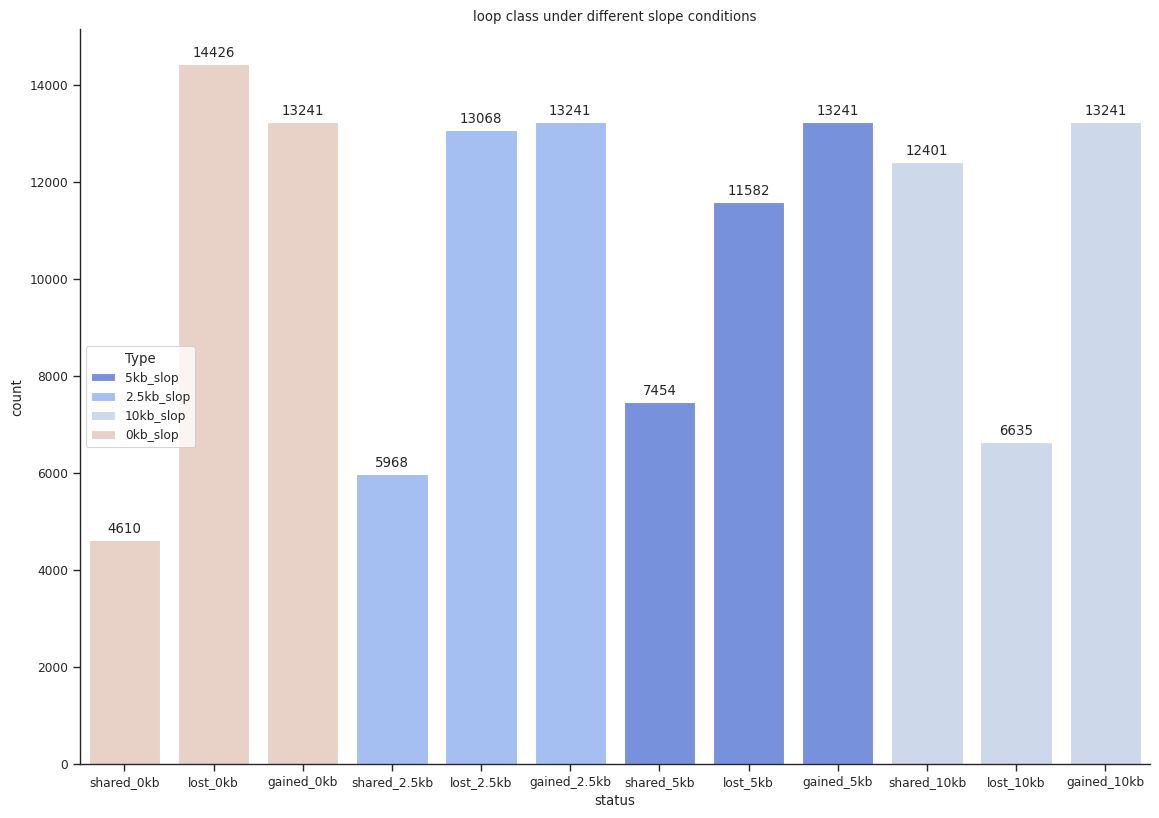

In [19]:
# Remap legend (Type)
type_mapping = {
    "status": "5kb_slop",
    "status_slop": "2.5kb_slop",
    "status_slop2": "10kb_slop",
    "status_slop3": "0kb_slop"
}
df_melted['Type'] = df_melted['Type'].map(type_mapping)

# Remap x-axis (Class)
class_mapping = {
    "shared": "shared_5kb",
    "lost": "lost_5kb",
    "gained": "gained_5kb",
    "shared_2.5kb": "shared_2.5kb",
    "lost_2.5kb": "lost_2.5kb",
    "gained_2.5kb": "gained_2.5kb",
    "shared_10kb": "shared_10kb",
    "lost_10kb": "lost_10kb",
    "gained_10kb": "gained_10kb",
    "shared_0kb": "shared_0kb",
    "lost_0kb": "lost_0kb",
    "gained_0kb": "gained_0kb"
}
df_melted['Class'] = df_melted['Class'].map(class_mapping)

# Set custom order for Class (x-axis)
custom_order = [
    "shared_0kb", "lost_0kb", "gained_0kb",
    "shared_2.5kb", "lost_2.5kb", "gained_2.5kb",
    "shared_5kb", "lost_5kb", "gained_5kb",
    "shared_10kb", "lost_10kb", "gained_10kb"
]
df_melted['Class'] = pd.Categorical(df_melted['Class'], categories=custom_order, ordered=True)

# Plot
sns.set_theme(style="ticks", rc={"axes.spines.top": False, "axes.spines.right": False, 'figure.figsize': (11.7, 8.27)})
sns.set_context("paper")
sns.set_palette("coolwarm")

ax = sns.countplot(data=df_melted, x='Class', hue='Type', order=custom_order)

# Add bar labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3)

# Set labels and title
ax.set(
    title="loop class under different slope conditions",
    xlabel="status",
    ylabel="count"
)

plt.tight_layout()
plt.show()

In [20]:
all_loops.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'chr1', 'start1', 'end1', 'chr2',
       'start2', 'end2', 'status', 'ctrl_signal', 'rbp1_signal', 'log2FC',
       'log2FC_clipped', 'condition', 'distance', 'loop_id', 'comp_switch_A1',
       'comp_switch_A2', 'loop_class', 'source', 'CTCF_signal',
       'H3K27me3_signal', 'H3K4me3_signal', 'rad21_signal', 'GC_mean',
       'GC_diff', 'E1_anchor1_ctrl', 'E1_anchor1_rbp1', 'E1_anchor2_ctrl',
       'E1_anchor2_rbp1', 'delta_E1_anchor1', 'delta_E1_anchor2',
       'ATAC_signal', 'status_slop', 'status_slop2', 'status_slop3'],
      dtype='object')

In [21]:
all_loops.to_csv("ml_final2_multimodal.csv")

In [22]:
all_loops[all_loops["status"] == "shared"]

,Unnamed: 0.1,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,...,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,ATAC_signal,status_slop,status_slop2,status_slop3
0,0,0,chr1,1952500,1957500,chr1,2042500,2047500,shared,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.078179,shared_2.5kb,shared_10kb,shared_0kb
1,1,1,chr1,2202500,2207500,chr1,2382500,2387500,shared,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.200288,shared_2.5kb,shared_10kb,shared_0kb
2,2,2,chr1,2412500,2417500,chr1,2552500,2557500,shared,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.069768,shared_2.5kb,shared_10kb,shared_0kb
3,3,3,chr1,3490000,3495000,chr1,3615000,3620000,shared,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.050523,shared_2.5kb,shared_10kb,shared_0kb
4,4,4,chr1,3565000,3570000,chr1,3615000,3620000,shared,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.067897,shared_2.5kb,shared_10kb,shared_0kb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7449,7449,7449,chrY,10992500,10997500,chrY,11722500,11727500,shared,0.003073,...,0.582211,0.593821,0.407110,0.471699,0.011609,0.064588,0.032901,lost_2.5kb,shared_10kb,lost_0kb
7450,7450,7450,chrY,11002500,11007500,chrY,11292500,11297500,shared,0.006270,...,0.458706,0.567977,0.330207,0.297400,0.109271,-0.032807,0.038712,lost_2.5kb,shared_10kb,lost_0kb
7451,7451,7451,chrY,11522500,11527500,chrY,11712500,11717500,shared,0.006805,...,0.330207,0.297400,-0.180873,-0.181410,-0.032807,-0.000537,0.092389,lost_2.5kb,shared_10kb,lost_0kb
7452,7452,7452,chrY,11525000,11530000,chrY,11680000,11685000,shared,0.011736,...,-0.324720,-0.242025,-0.903052,-0.989166,0.082695,-0.086114,0.037766,lost_2.5kb,shared_10kb,lost_0kb


In [23]:
all_loops[all_loops["status"] == "gained"]

,Unnamed: 0.1,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,...,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,ATAC_signal,status_slop,status_slop2,status_slop3
19036,19036,19036,chr1,3910000,3915000,chr1,4065000,4070000,gained,0.011669,...,-0.883032,-0.683250,-0.664671,-0.585173,0.199783,0.079498,0.046918,gained_2.5kb,gained_10kb,gained_0kb
19037,19037,19037,chr1,3910000,3915000,chr1,4155000,4160000,gained,0.006800,...,-0.697600,-0.617999,-0.077739,-0.155731,0.079601,-0.077992,0.058400,gained_2.5kb,gained_10kb,gained_0kb
19038,19038,19038,chr1,5502500,5507500,chr1,5732500,5737500,gained,0.006607,...,-0.087118,-0.190688,-0.440078,-0.428727,-0.103570,0.011350,0.039555,gained_2.5kb,gained_10kb,gained_0kb
19039,19039,19039,chr1,5632500,5637500,chr1,5752500,5757500,gained,0.019869,...,-0.087118,-0.190688,-0.243000,-0.356334,-0.103570,-0.113334,0.046473,gained_2.5kb,gained_10kb,gained_0kb
19040,19040,19040,chr1,6710000,6715000,chr1,7140000,7145000,gained,0.003147,...,-0.312568,-0.320551,-0.326684,-0.284346,-0.007983,0.042337,0.141996,gained_2.5kb,gained_10kb,gained_0kb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32272,32272,32272,chrY,10945000,10950000,chrY,11290000,11295000,gained,0.006078,...,-0.064836,-0.140925,0.270996,0.177009,-0.076090,-0.093987,0.019050,gained_2.5kb,gained_10kb,gained_0kb
32273,32273,32273,chrY,10982500,10987500,chrY,11292500,11297500,gained,0.007661,...,0.120802,-0.100746,0.270996,0.177009,-0.221548,-0.093987,0.022277,gained_2.5kb,gained_10kb,gained_0kb
32274,32274,32274,chrY,11292500,11297500,chrY,11722500,11727500,gained,0.001017,...,0.270996,0.177009,0.409095,0.332632,-0.093987,-0.076464,0.022359,gained_2.5kb,gained_10kb,gained_0kb
32275,32275,32275,chrY,11530000,11535000,chrY,11760000,11765000,gained,0.004674,...,-1.192141,-1.204536,-1.229772,-1.167283,-0.012394,0.062489,0.019858,gained_2.5kb,gained_10kb,gained_0kb


In [24]:
all_loops[all_loops["status"] == "lost"]

,Unnamed: 0.1,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,...,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,ATAC_signal,status_slop,status_slop2,status_slop3
7454,7454,7454,chr1,3912500,3917500,chr1,4592500,4597500,lost,0.007892,...,-0.715011,-0.713781,-0.852452,-0.899026,0.001230,-0.046574,0.062544,lost_2.5kb,shared_10kb,lost_0kb
7455,7455,7455,chr1,5502500,5507500,chr1,5742500,5747500,lost,0.010166,...,-0.822759,-0.837333,-0.749237,-0.851246,-0.014575,-0.102009,0.104490,lost_2.5kb,shared_10kb,lost_0kb
7456,7456,7456,chr1,5632500,5637500,chr1,5742500,5747500,lost,0.041111,...,-0.675872,-0.703469,-0.531544,-0.604361,-0.027597,-0.072818,0.065398,lost_2.5kb,shared_10kb,lost_0kb
7457,7457,7457,chr1,5635000,5640000,chr1,5980000,5985000,lost,0.003995,...,-0.532789,-0.560222,-0.510784,-0.561599,-0.027433,-0.050814,0.042581,lost_2.5kb,shared_10kb,lost_0kb
7458,7458,7458,chr1,6555000,6560000,chr1,6645000,6650000,lost,0.022830,...,-0.587641,-0.577899,0.077792,0.055617,0.009741,-0.022175,0.045341,lost_2.5kb,shared_10kb,lost_0kb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19031,19031,19031,chrX,114462500,114467500,chrX,114602500,114607500,lost,0.017679,...,0.233206,0.297484,-0.029244,0.151352,0.064278,0.180596,0.035663,lost_2.5kb,lost_10kb,lost_0kb
19032,19032,19032,chrX,132022500,132027500,chrX,132212500,132217500,lost,0.016384,...,0.239816,0.359202,0.319974,0.310146,0.119386,-0.009828,0.046739,lost_2.5kb,lost_10kb,lost_0kb
19033,19033,19033,chrY,10820000,10825000,chrY,11290000,11295000,lost,0.003529,...,-0.043128,0.118664,-0.458564,-0.308422,0.161791,0.150142,0.069602,lost_2.5kb,lost_10kb,lost_0kb
19034,19034,19034,chrY,11302500,11307500,chrY,11722500,11727500,lost,0.001016,...,0.688614,0.584860,0.434836,0.555058,-0.103754,0.120222,0.039460,lost_2.5kb,lost_10kb,lost_0kb


In [25]:
# export here allsharedloops_5kbslop, allgainedloops_5kbslop, alllostloops_5kbslop

In [26]:
#all_loops_df = all_loops.to_dataframe()
shared_all = all_loops[all_loops["status"] == "shared"]
gained_all = all_loops[all_loops["status"] == "gained"]
lost_all = all_loops[all_loops["status"] == "lost"]
shared_all.to_csv("allsharedloops_5kbslop.csv", index=False)
gained_all.to_csv("allgainedloops_5kbslop.csv", index=False)
lost_all.to_csv("alllostloops_5kbslop.csv", index=False)

In [27]:
shared_all.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'chr1', 'start1', 'end1', 'chr2',
       'start2', 'end2', 'status', 'ctrl_signal', 'rbp1_signal', 'log2FC',
       'log2FC_clipped', 'condition', 'distance', 'loop_id', 'comp_switch_A1',
       'comp_switch_A2', 'loop_class', 'source', 'CTCF_signal',
       'H3K27me3_signal', 'H3K4me3_signal', 'rad21_signal', 'GC_mean',
       'GC_diff', 'E1_anchor1_ctrl', 'E1_anchor1_rbp1', 'E1_anchor2_ctrl',
       'E1_anchor2_rbp1', 'delta_E1_anchor1', 'delta_E1_anchor2',
       'ATAC_signal', 'status_slop', 'status_slop2', 'status_slop3'],
      dtype='object')

In [28]:
shared_all.loc[:, ['chr1', 'start1', 'end1', 'chr2',
       'start2', 'end2', "CTCF_signal", "H3K27me3_signal", "H3K4me3_signal", "rad21_signal", "ATAC_signal"]]

,chr1,start1,end1,chr2,start2,end2,CTCF_signal,H3K27me3_signal,H3K4me3_signal,rad21_signal,ATAC_signal
0,chr1,1952500,1957500,chr1,2042500,2047500,3.719732,1.930504,0.188543,0.024018,0.078179
1,chr1,2202500,2207500,chr1,2382500,2387500,62.158684,1.542050,0.566125,0.063427,0.200288
2,chr1,2412500,2417500,chr1,2552500,2557500,13.704273,4.520206,0.188543,0.044699,0.069768
3,chr1,3490000,3495000,chr1,3615000,3620000,1.076765,5.414830,0.188543,0.024769,0.050523
4,chr1,3565000,3570000,chr1,3615000,3620000,16.477770,1.377250,0.188543,0.042592,0.067897
...,...,...,...,...,...,...,...,...,...,...,...
7449,chrY,10992500,10997500,chrY,11722500,11727500,0.522068,0.176570,0.221311,0.024772,0.032901
7450,chrY,11002500,11007500,chrY,11292500,11297500,0.000000,0.000000,0.202366,0.026853,0.038712
7451,chrY,11522500,11527500,chrY,11712500,11717500,2.806113,0.329598,0.570473,0.033382,0.092389
7452,chrY,11525000,11530000,chrY,11680000,11685000,2.153530,0.094171,0.203163,0.027965,0.037766


In [29]:
gained_all.loc[:, ['chr1', 'start1', 'end1', 'chr2',
       'start2', 'end2', "CTCF_signal", "H3K27me3_signal", "H3K4me3_signal", "rad21_signal", "ATAC_signal"]]

,chr1,start1,end1,chr2,start2,end2,CTCF_signal,H3K27me3_signal,H3K4me3_signal,rad21_signal,ATAC_signal
19036,chr1,3910000,3915000,chr1,4065000,4070000,8.353086,0.188342,0.188543,0.047741,0.046918
19037,chr1,3910000,3915000,chr1,4155000,4160000,9.495104,0.282513,0.240568,0.052827,0.058400
19038,chr1,5502500,5507500,chr1,5732500,5737500,4.927012,0.282513,0.190101,0.037450,0.039555
19039,chr1,5632500,5637500,chr1,5752500,5757500,9.364593,9.405324,0.188543,0.050534,0.046473
19040,chr1,6710000,6715000,chr1,7140000,7145000,11.877039,0.188342,0.303614,0.037448,0.141996
...,...,...,...,...,...,...,...,...,...,...,...
32272,chrY,10945000,10950000,chrY,11290000,11295000,0.000000,0.000000,0.188543,0.026824,0.019050
32273,chrY,10982500,10987500,chrY,11292500,11297500,0.522068,0.188342,0.249019,0.130330,0.022277
32274,chrY,11292500,11297500,chrY,11722500,11727500,0.261034,0.082400,0.241160,0.123878,0.022359
32275,chrY,11530000,11535000,chrY,11760000,11765000,0.293663,0.188342,0.214433,0.112741,0.019858


In [30]:
lost_all.loc[:, ['chr1', 'start1', 'end1', 'chr2',
       'start2', 'end2',"CTCF_signal", "H3K27me3_signal", "H3K4me3_signal", "rad21_signal", "ATAC_signal"]]

,chr1,start1,end1,chr2,start2,end2,CTCF_signal,H3K27me3_signal,H3K4me3_signal,rad21_signal,ATAC_signal
7454,chr1,3912500,3917500,chr1,4592500,4597500,1.500945,0.753367,0.188543,0.024675,0.062544
7455,chr1,5502500,5507500,chr1,5742500,5747500,17.097721,0.188342,0.727908,0.033591,0.104490
7456,chr1,5632500,5637500,chr1,5742500,5747500,2.838743,8.016302,0.245351,0.023113,0.065398
7457,chr1,5635000,5640000,chr1,5980000,5985000,0.880990,1.318394,0.272891,0.023068,0.042581
7458,chr1,6555000,6560000,chr1,6645000,6650000,4.992271,0.153028,0.188543,0.025681,0.045341
...,...,...,...,...,...,...,...,...,...,...,...
19031,chrX,114462500,114467500,chrX,114602500,114607500,2.871373,0.871081,0.195728,0.047586,0.035663
19032,chrX,132022500,132027500,chrX,132212500,132217500,4.111284,0.553254,0.216570,0.041890,0.046739
19033,chrY,10820000,10825000,chrY,11290000,11295000,7.276319,0.376684,0.363582,0.053156,0.069602
19034,chrY,11302500,11307500,chrY,11722500,11727500,1.305169,0.094171,0.188543,0.026308,0.039460


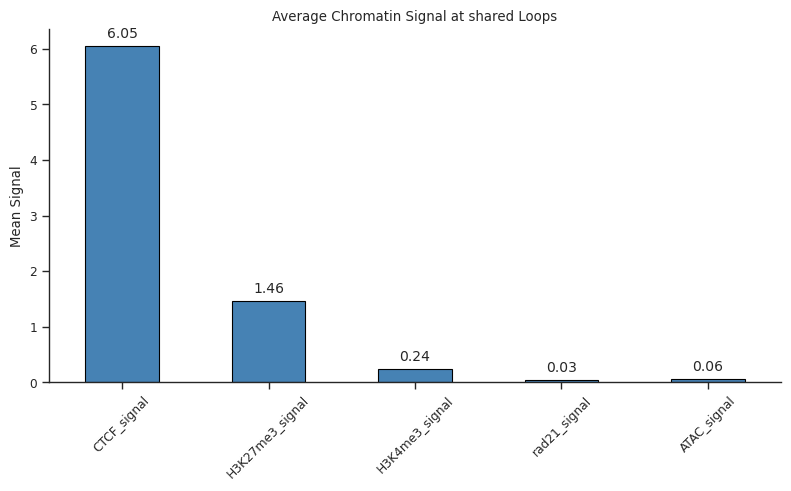

In [31]:
# Compute mean signals
mean_signals = shared_all[["CTCF_signal", "H3K27me3_signal", "H3K4me3_signal", "rad21_signal", "ATAC_signal"]].mean()

# Plot
plt.figure(figsize=(8, 5))
ax = mean_signals.plot(kind='bar', color='steelblue', edgecolor='black')

# Add values on top of bars
for i, value in enumerate(mean_signals):
    ax.text(i, value + 0.1, f"{value:.2f}", ha='center', va='bottom', fontsize=10)

plt.ylabel("Mean Signal")
plt.title("Average Chromatin Signal at shared Loops")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

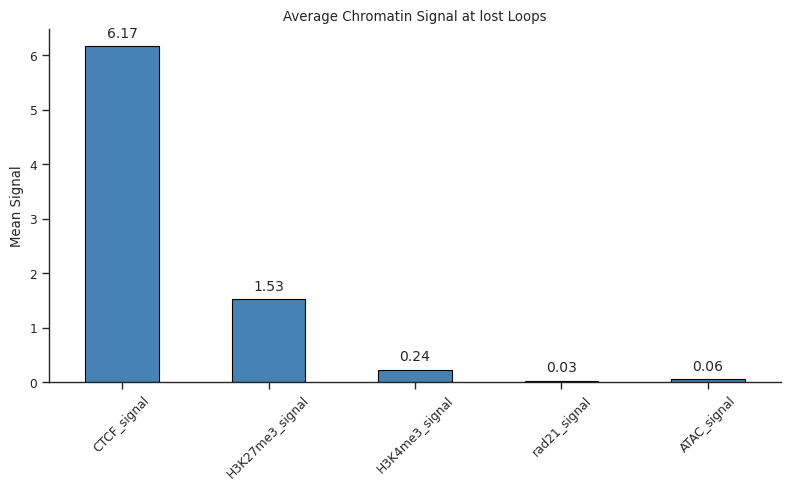

In [32]:
# Compute mean signals
mean_signals = lost_all[["CTCF_signal", "H3K27me3_signal", "H3K4me3_signal", "rad21_signal", "ATAC_signal"]].mean()

# Plot
plt.figure(figsize=(8, 5))
ax = mean_signals.plot(kind='bar', color='steelblue', edgecolor='black')

# Add values on top of bars
for i, value in enumerate(mean_signals):
    ax.text(i, value + 0.1, f"{value:.2f}", ha='center', va='bottom', fontsize=10)

plt.ylabel("Mean Signal")
plt.title("Average Chromatin Signal at lost Loops")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

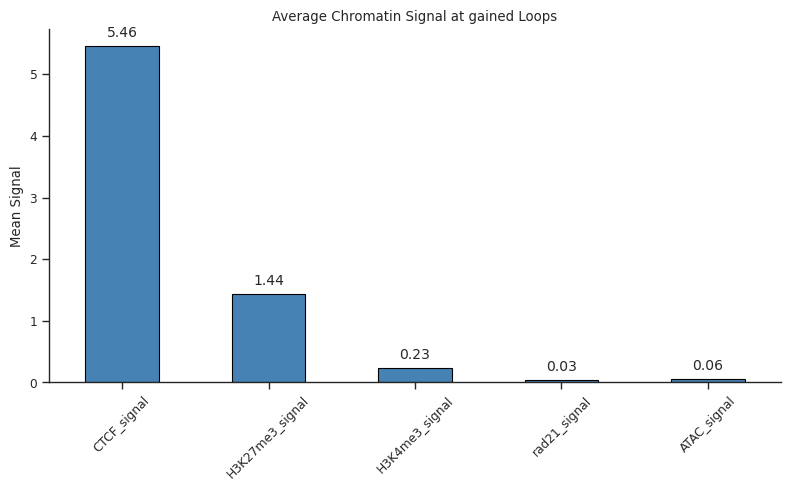

In [33]:
# Compute mean signals
mean_signals = gained_all[["CTCF_signal", "H3K27me3_signal", "H3K4me3_signal", "rad21_signal", "ATAC_signal"]].mean()

# Plot
plt.figure(figsize=(8, 5))
ax = mean_signals.plot(kind='bar', color='steelblue', edgecolor='black')

# Add values on top of bars
for i, value in enumerate(mean_signals):
    ax.text(i, value + 0.1, f"{value:.2f}", ha='center', va='bottom', fontsize=10)

plt.ylabel("Mean Signal")
plt.title("Average Chromatin Signal at gained Loops")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

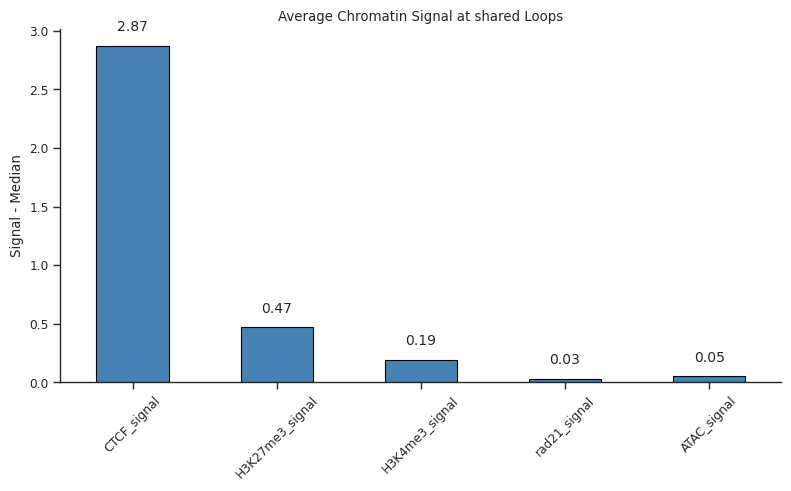

In [34]:
# Compute median signals
median_signals = shared_all[["CTCF_signal", "H3K27me3_signal", "H3K4me3_signal", "rad21_signal", "ATAC_signal"]].median()

# Plot
plt.figure(figsize=(8, 5))
ax = median_signals.plot(kind='bar', color='steelblue', edgecolor='black')

# Add values on top of bars
for i, value in enumerate(median_signals):
    ax.text(i, value + 0.1, f"{value:.2f}", ha='center', va='bottom', fontsize=10)

plt.ylabel("Signal - Median")
plt.title("Average Chromatin Signal at shared Loops")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

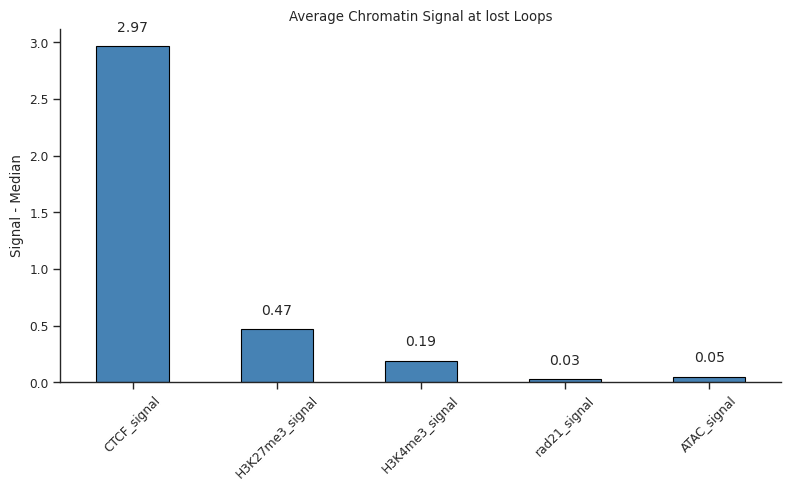

In [35]:
# Compute median signals
median_signals = lost_all[["CTCF_signal", "H3K27me3_signal", "H3K4me3_signal", "rad21_signal", "ATAC_signal"]].median()

# Plot
plt.figure(figsize=(8, 5))
ax = median_signals.plot(kind='bar', color='steelblue', edgecolor='black')

# Add values on top of bars
for i, value in enumerate(median_signals):
    ax.text(i, value + 0.1, f"{value:.2f}", ha='center', va='bottom', fontsize=10)

plt.ylabel("Signal - Median")
plt.title("Average Chromatin Signal at lost Loops")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

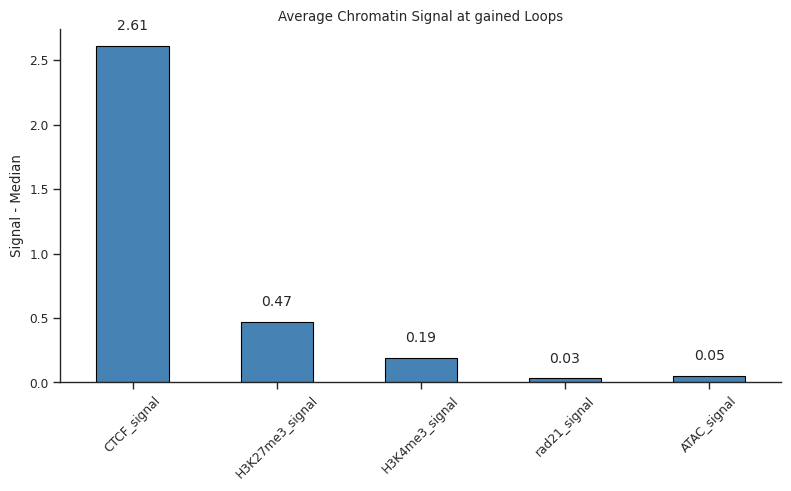

In [36]:
# Compute median signals
median_signals = gained_all[["CTCF_signal", "H3K27me3_signal", "H3K4me3_signal", "rad21_signal", "ATAC_signal"]].median()

# Plot
plt.figure(figsize=(8, 5))
ax = median_signals.plot(kind='bar', color='steelblue', edgecolor='black')

# Add values on top of bars
for i, value in enumerate(median_signals):
    ax.text(i, value + 0.1, f"{value:.2f}", ha='center', va='bottom', fontsize=10)

plt.ylabel("Signal - Median")
plt.title("Average Chromatin Signal at gained Loops")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [40]:
shared_all.loc[:, ["comp_switch_A1", "comp_switch_A2"]]

,comp_switch_A1,comp_switch_A2
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
...,...,...
7449,stable,stable
7450,stable,stable
7451,stable,stable
7452,stable,stable
